In [ ]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns

from reconstruction_comparison import *
import csiborgtools

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
h = 0.6766
cosmo = {"h": h, "Om": 0.3111, "Ob": 0.02242 / h**2, "ns": 0.9665,
         "tau": 0.0561, "mnu": 0, "w0": -1, "wa": 0, "As": 2.105}


In [62]:
f_nonlinear_to_linear_sigma8 = csiborgtools.flow.make_nonlinear_to_linear_sigma8(0.5, 1.2, 1000, **cosmo)

Computing linear sigma8: 100%|██████████| 1000/1000 [00:26<00:00, 38.36it/s]


### Compare Deaglan's result to Juszkiewicz

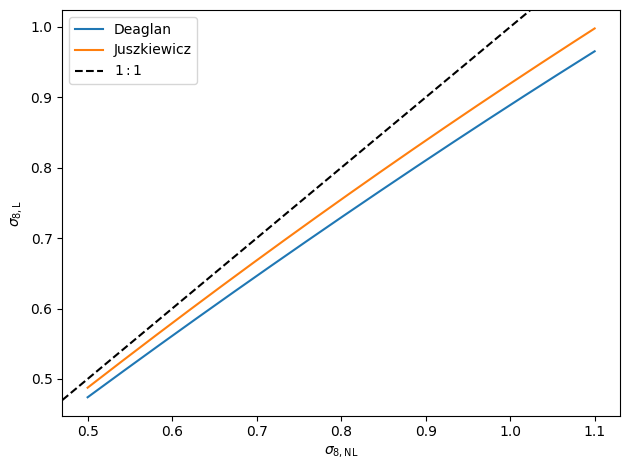

In [64]:
plt.figure()

x = np.linspace(0.5, 1.1, 1000)
plt.plot(x, f_nonlinear_to_linear_sigma8(x), label="Deaglan")
plt.plot(x, csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(x), label="Juszkiewicz")
plt.axline((0.5, 0.5), slope=1, color='k', linestyle='--', c="black", label=r"$1:1$")

plt.legend()

plt.xlabel(r"$\sigma_{8, \mathrm{NL}}$")
plt.ylabel(r"$\sigma_{8, \mathrm{L}}$")
plt.tight_layout()
# plt.savefig("../../plots/sigma8_nl_to_l_comparison.png", dpi=450)

plt.show()

In [171]:
simname = "Carrick2015"

fname = paths.flow_validation(
    fdir, simname, catalogue="CF4_TFR_i", inference_method="bayes",
    sample_alpha=True, sample_beta=None,
    zcmb_max=0.05)

beta_CF4_TFR_i = get_some_samples(fname, ["beta"])["beta"]


def compute_fsigma8_nonlinear(beta, which_sigma8g):
    if which_sigma8g == "westover":
        sigma8g_mean = 0.98
        sigma8g_std = 0.07
    elif which_sigma8g == "carrick":
        sigma8g_mean = 0.99
        sigma8g_std = 0.04
    else:
        raise ValueError(f"`which_sigma8g` {which_sigma8g} not recognized")
    
    sigma8g = np.random.normal(sigma8g_mean, sigma8g_std, size=len(beta))
    return beta * sigma8g

def compute_sigma8_nonlinear(fsig8_nonlinear, Om0, gamma=6/11):
    return fsig8_nonlinear / (Om0**gamma)


# sig8_linear_planck = np.random.normal(0.8159, 0.0086, size=len(beta))

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_i_bayes_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 12/09/2024 12:20:11


### Plot of $f \sigma_{8, \mathrm{NL}}$

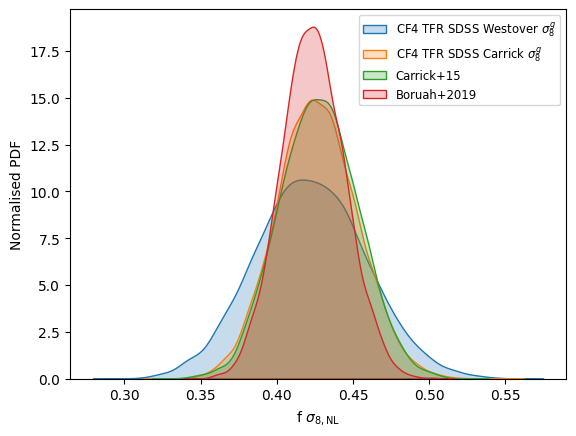

In [172]:
from scipy.stats import norm

if True:
    plt.figure()
    sns.kdeplot(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "westover"),
                label=r"CF4 TFR SDSS Westover $\sigma_8^g$", fill=True)
    sns.kdeplot(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "carrick"),
                label=r"CF4 TFR SDSS Carrick $\sigma_8^g$", fill=True)


    xs = norm(0.427, 0.026).rvs(size=10_000)
    sns.kdeplot(xs, label=simname_to_pretty("Carrick2015"), fill=True)


    betas_boruah = norm(0.428, 0.012).rvs(size=10_000)
    sns.kdeplot(compute_fsigma8_nonlinear(betas_boruah, "carrick"), label="Boruah+2019", fill=True)

    plt.xlabel(r"f $\sigma_{8, \mathrm{NL}}$")
    plt.ylabel(r"Normalised PDF")
    plt.legend(fontsize="small")
    plt.savefig("../../plots/fsigma8_nl_comparison.png", dpi=450)
    plt.show()


### Plot of $f \sigma_{8, \mathrm{L}}$

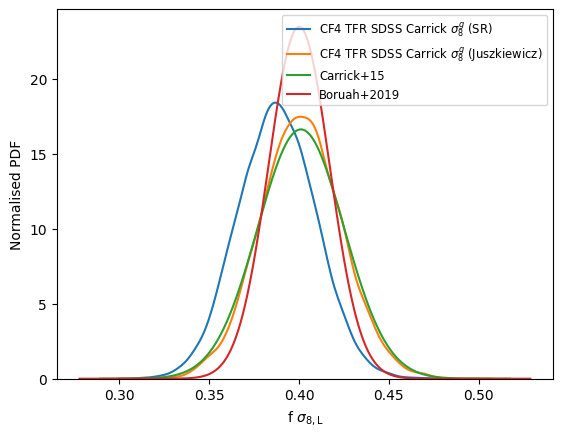

In [173]:
def fsigma8_nonlinear_to_linear(fsigma8_nonlinear, Om0, gamma=6/11, which="sr"):
    sigma8_nonlinear = fsigma8_nonlinear / Om0**gamma

    if which == "sr":
        return f_nonlinear_to_linear_sigma8(sigma8_nonlinear) * Om0**gamma
    elif which == "juszkiewicz":
        return csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(sigma8_nonlinear) * Om0**gamma
    else:
        raise ValueError(f"`which` {which} not recognized")


fill = False

plt.figure()
sns.kdeplot(fsigma8_nonlinear_to_linear(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "carrick"), 0.3, which="sr"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (SR)",)
sns.kdeplot(fsigma8_nonlinear_to_linear(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "carrick"), 0.3, which="juszkiewicz"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (Juszkiewicz)",)

d = norm(0.401, 0.024)
xs = np.linspace(*plt.xlim(), 1000)
plt.plot(xs, d.pdf(xs), label=simname_to_pretty("Carrick2015"))

d = norm(0.400, 0.017)
xs = np.linspace(*plt.xlim(), 1000)
plt.plot(xs, d.pdf(xs), label="Boruah+2019")


plt.xlabel(r"f $\sigma_{8, \mathrm{L}}$")
plt.ylabel(r"Normalised PDF")
plt.legend(fontsize="small")
plt.savefig("../../plots/fsigma8_linear_comparison.png", dpi=450)

plt.show()


### Plot of $S_8$

In [174]:
def fsigma8_nonlinear_to_S8(fsigma8_nonlinear, Om0, gamma=0.55, which="sr"):
    sigma8_nonlinear = fsigma8_nonlinear / Om0**gamma

    if which == "sr":
        sigma8_linear = f_nonlinear_to_linear_sigma8(sigma8_nonlinear)
    elif which == "juszkiewicz":
        sigma8_linear = csiborgtools.flow.sigma8_nonlinear_to_linear_juszkiewicz(sigma8_nonlinear)
    else:
        raise ValueError(f"`which` {which} not recognized")

    return sigma8_linear * (Om0 / 0.3)**gamma
    

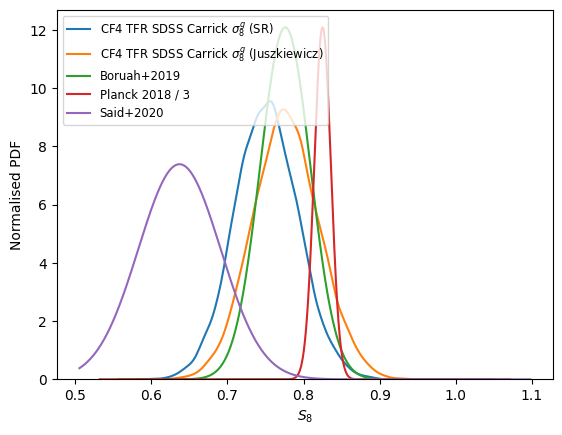

In [177]:
fill = False

plt.figure()
sns.kdeplot(fsigma8_nonlinear_to_S8(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "carrick"), 0.3, which="sr"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (SR)",)
sns.kdeplot(fsigma8_nonlinear_to_S8(compute_fsigma8_nonlinear(beta_CF4_TFR_i, "carrick"), 0.3, which="juszkiewicz"),
            fill=fill, label=r"CF4 TFR SDSS Carrick $\sigma_8^g$ (Juszkiewicz)",)


d = norm(0.776, 0.033)
xs = np.linspace(*plt.xlim(), 10000)
plt.plot(xs, d.pdf(xs), label="Boruah+2019")

d = norm(0.825, 0.011)
xs = np.linspace(*plt.xlim(), 10000)
plt.plot(xs, d.pdf(xs) / 3, label="Planck 2018 / 3")

d = norm(0.637, 0.054)
xs = np.linspace(*plt.xlim(), 10000)
plt.plot(xs, d.pdf(xs), label="Said+2020")

plt.xlabel(r"$S_8$")
plt.ylabel(r"Normalised PDF")
plt.legend(fontsize="small", loc="upper left")
plt.savefig("../../plots/S8_comparison.png", dpi=450)

plt.show()